In [3]:
import pickle
import warnings
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')


# 1. Data Loading and Preparation

In [4]:
df = pd.read_csv('churn_jaipur_updated.csv')
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,8303189417,Rathore,623,Jaipur Gramin,Female,42,2,0.00,1,1,1,8614654.80,1
1,2,8337334548,Gupta,610,Jaipur City,Female,41,1,7123668.10,1,0,1,9566119.30,0
2,3,8611032290,Khandelwal,482,Jaipur Gramin,Female,42,8,13571168.00,3,1,0,9684183.45,1
3,4,8354644712,Maheshwari,719,Jaipur Gramin,Female,39,1,0.00,2,0,0,7975263.55,0
4,5,8848478759,Singh,900,Jaipur City,Female,43,2,10668419.70,1,1,1,6722148.50,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,8964816218,Meena,805,Jaipur Gramin,Male,39,5,0.00,2,1,0,8183004.40,0
9996,9997,8828993037,Sharma,499,Jaipur Gramin,Male,35,10,4876416.85,1,1,1,8644480.45,0
9997,9998,8262448431,Sharma,731,Jaipur Gramin,Female,36,7,0.00,1,0,1,3577274.30,1
9998,9999,8570122854,Khandelwal,806,Jaipur Urban,Male,42,3,6381401.35,2,1,0,7895524.20,1


In [5]:
df['Geography'] = df['Geography'].str.strip().str.replace(r'\s+', ' ', regex=True)

In [6]:
# Check for any missing or duplicate records in the dataset. 
df.isnull().sum()# checking the missing values---> no missing value found


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.duplicated().sum()# check for duplicate records--->no duplicates

0

In [8]:
print(df['Geography'].value_counts())
print(df['Geography'].unique())

Geography
Jaipur Gramin    5014
Jaipur Urban     2509
Jaipur City      2477
Name: count, dtype: int64
['Jaipur Gramin' 'Jaipur City' 'Jaipur Urban']


In [9]:
# Convert the categorical columns Geography and Gender into appropriate numerical formats using label encoding or one-hot encoding.



In [10]:
df['Geography'] = df.Geography.astype('category')
df['Geography'] =df.Geography.cat.codes
df['Gender'] = df.Gender.astype('category')
df['Gender'] =df.Gender.cat.codes
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,8303189417,Rathore,623,1,0,42,2,0.00,1,1,1,8614654.80,1
1,2,8337334548,Gupta,610,0,0,41,1,7123668.10,1,0,1,9566119.30,0
2,3,8611032290,Khandelwal,482,1,0,42,8,13571168.00,3,1,0,9684183.45,1
3,4,8354644712,Maheshwari,719,1,0,39,1,0.00,2,0,0,7975263.55,0
4,5,8848478759,Singh,900,0,0,43,2,10668419.70,1,1,1,6722148.50,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,8964816218,Meena,805,1,1,39,5,0.00,2,1,0,8183004.40,0
9996,9997,8828993037,Sharma,499,1,1,35,10,4876416.85,1,1,1,8644480.45,0
9997,9998,8262448431,Sharma,731,1,0,36,7,0.00,1,0,1,3577274.30,1
9998,9999,8570122854,Khandelwal,806,2,1,42,3,6381401.35,2,1,0,7895524.20,1


# 2. Churn Rate Analysis

In [11]:
# Calculate the overall churn rate in the dataset. Display both the count and the percentage of customers who exited.

churn_count=df['Exited'].sum()
print(f'Total No of churn_count: {churn_count}')
Total_Customer = df.shape[0]
print(f'Total No of Customers: {Total_Customer}')
churn_percentage=churn_count/len(df)*100
print(f"churn_percentage:{churn_percentage:.2f}%")

Total No of churn_count: 2037
Total No of Customers: 10000
churn_percentage:20.37%


In [12]:
#Group the data by Geography and calculate the churn rate for each country. Sort the result by churn rate in descending order
churn_rate_by_geography=df.groupby('Geography')['Exited'].mean().round(2)*100
churn_rate_by_geography=churn_rate_by_geography.sort_values(ascending=False)
print(churn_rate_by_geography)

Geography
2    32.0
0    17.0
1    16.0
Name: Exited, dtype: float64


# 3. Demographics and Churn

In [13]:
#average age of customers who churned versus those who did not? Provide a comparison summary.

avg_age_churned=df[df['Exited']==1]['Age'].mean()

print(f"avg_age_of churned:{avg_age_churned:.2f}")
avg_age_non_churned=df[df['Exited']==0]['Age'].mean()
print(f"avg_age_of non_churned:{avg_age_non_churned:.2f}")



avg_age_of churned:44.84
avg_age_of non_churned:37.41


In [14]:
#Determine the percentage of churned customers are aged over 45. Compare it to their overall percentage in the dataset
#calculate percentage of churned customer
churned_over_45=df[(df['Exited']==1) & (df['Age']>45)].shape[0]
total_churned= df[df['Exited']==1].shape[0]
percentage_churned_over_45=(churned_over_45/total_churned)*100
# calculate overall percentage of customers aged over 45
total_over_45= df[df['Age']>45].shape[0] 
percentage_over_45=(total_over_45/len(df))*100               
print(f'Percentage of churned customer above 45: {percentage_churned_over_45 :.2f} %')
print(f'Overall percentage of customers age above 45: {percentage_over_45 :.2f} %')

Percentage of churned customer above 45: 46.98 %
Overall percentage of customers age above 45: 21.11 %


In [15]:
# Analyze churn rate by Gender. 
Gen_churn_rate =(df.groupby(['Gender'])['Exited'].mean()*100).round(2)
Gen_churn_rate # Female seems to be more churned compare to males

Gender
0    25.07
1    16.46
Name: Exited, dtype: float64

# 4. Product & Account Insights

In [16]:
#Analyze the churn rate based on NumOfProducts. Create a summary table showing churn rate for 1, 2, 3, and 4 products.

df.groupby('NumOfProducts')['Exited'].mean()


NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64

In [17]:
#Among customers with a Balance of zero, what percentage have exited the bank?
Bal_zero_total= df[(df.Balance==0)]
Bal_zero_Exit= Bal_zero_total.Exited.sum()
per_bal_zero_exit = (Bal_zero_Exit/Bal_zero_total.shape[0]*100).round(2)
print(f' Percentage of cutomers having zero balance and exited: {per_bal_zero_exit:.2f} %')

 Percentage of cutomers having zero balance and exited: 13.82 %


In [18]:
# average tenure of customers who churned compared to those who didn’t?
cus_avg_tenure = df.groupby('Exited')['Tenure'].mean().round(2)
cus_avg_tenure

Exited
0    5.03
1    4.93
Name: Tenure, dtype: float64

# 5. Credit and Financial Insights

In [19]:
# churn rates for customers with:
#•CreditScore < 600
#•CreditScore > 800  What do these churn rates indicate?
Cr_score_churn_upto_600 = df[df.CreditScore<600].Exited.mean()*100
Cr_score_churn_above_800 = df[df.CreditScore>800].Exited.mean()*100
print(f'Churn rate for customers who has credit score < 600 : {Cr_score_churn_upto_600:.2f}%')
print(f'Churn rate for customers who has credit score > 800 : {Cr_score_churn_above_800:.2f}%')

Churn rate for customers who has credit score < 600 : 21.75%
Churn rate for customers who has credit score > 800 : 19.74%


In [20]:
# Among customers with a HasCrCard value of 0 and 1, compare the churn rates. Is holding a credit card correlated with retention?
Churn_rate_hascrcard = df.groupby('HasCrCard')['Exited'].mean()*100
Churn_rate_hascrcard 

HasCrCard
0    20.814941
1    20.184266
Name: Exited, dtype: float64

In [21]:
#Create a new column categorizing CreditScore as: 'Low' (<600), 'Medium' (600–800), 'High' (>800). Group by this category and show churn rate.
df['New_Credit_Score'] = df.CreditScore.apply(lambda x: 'Low' if x<600 else ('High' if x>800 else 'Medium'))
df


# Creating a New_Credit_Score column  with its category

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,New_Credit_Score
0,1,8303189417,Rathore,623,1,0,42,2,0.00,1,1,1,8614654.80,1,Medium
1,2,8337334548,Gupta,610,0,0,41,1,7123668.10,1,0,1,9566119.30,0,Medium
2,3,8611032290,Khandelwal,482,1,0,42,8,13571168.00,3,1,0,9684183.45,1,Low
3,4,8354644712,Maheshwari,719,1,0,39,1,0.00,2,0,0,7975263.55,0,Medium
4,5,8848478759,Singh,900,0,0,43,2,10668419.70,1,1,1,6722148.50,0,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,8964816218,Meena,805,1,1,39,5,0.00,2,1,0,8183004.40,0,High
9996,9997,8828993037,Sharma,499,1,1,35,10,4876416.85,1,1,1,8644480.45,0,Low
9997,9998,8262448431,Sharma,731,1,0,36,7,0.00,1,0,1,3577274.30,1,Medium
9998,9999,8570122854,Khandelwal,806,2,1,42,3,6381401.35,2,1,0,7895524.20,1,High


In [22]:
churn_rate_credit_score = (df.groupby('New_Credit_Score')['Exited'].mean()*100).round(2)
churn_rate_credit_score.sort_values()

New_Credit_Score
High      19.74
Medium    19.77
Low       21.75
Name: Exited, dtype: float64

# 6. Engagement and Salary Analysis

In [23]:
#Compare churn rates between active (IsActiveMember = 1) and inactive (IsActiveMember = 0) customers.

churn_rate_active=df[df['IsActiveMember']==1]['Exited'].mean()
churn_rate_inactive=df[df['IsActiveMember']==0]['Exited'].mean()
print(f"churn rate for active customers:{churn_rate_active:.2f}")
print(f"churn rate for inactive customers:{churn_rate_inactive:.2f}")

churn rate for active customers:0.14
churn rate for inactive customers:0.27


In [24]:
#average EstimatedSalary for churned vs non-churned customers? Is salary a clear churn factor?
 # yes salary is important churn factor
avg_salary_churned=df[df['Exited']==1]['EstimatedSalary'].mean()
avg_salary_nonchurned=df[df['Exited']==0]['EstimatedSalary'].mean()
print(f"avg_salary_churned customers:{avg_salary_churned:.2f}")
print(f"avg_salary_nonchurned customers:{avg_salary_nonchurned:.2f}")


avg_salary_churned customers:8624582.59
avg_salary_nonchurned customers:8477763.30


In [25]:
# top 5 surnames associated with the highest churn counts. 
df[df['Exited']==1]['Surname'].value_counts().head(5)

Surname
Choudhary     150
Khandelwal    149
Saini         147
Singh         147
Gupta         141
Name: count, dtype: int64

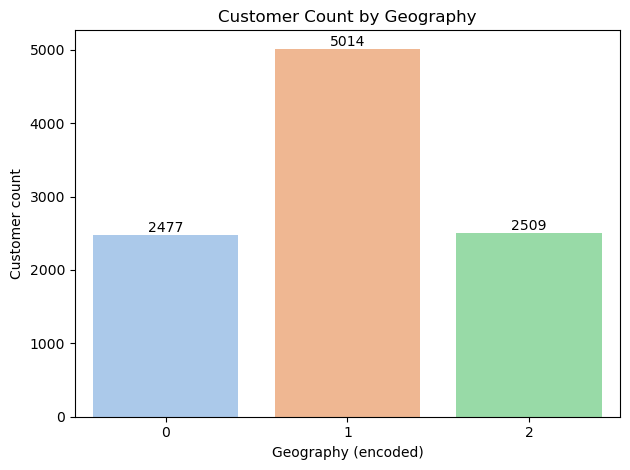

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
ax = sns.countplot(x='Geography', data=df, palette='pastel')
ax.set(title='Customer Count by Geography',
    xlabel='Geography (encoded)',
    ylabel='Customer count')

for bars in ax.containers:
    ax.bar_label(bars)

plt.tight_layout()
plt.show()

Gender
1    5457
0    4543
Name: count, dtype: int64


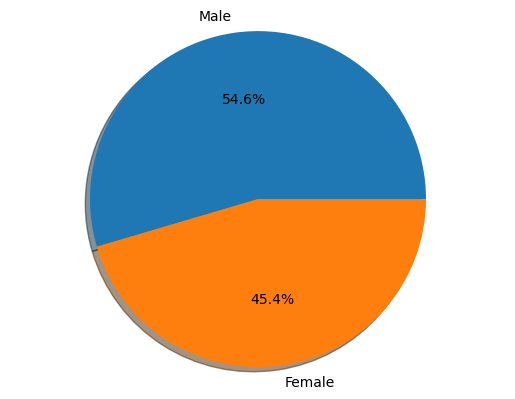

In [27]:
labels = ['Male','Female']
sizes = df['Gender'].value_counts()
print(sizes)
fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct='%1.1f%%', shadow=True)
ax1.axis('equal')
plt.show()

<Axes: xlabel='Geography', ylabel='Exited'>

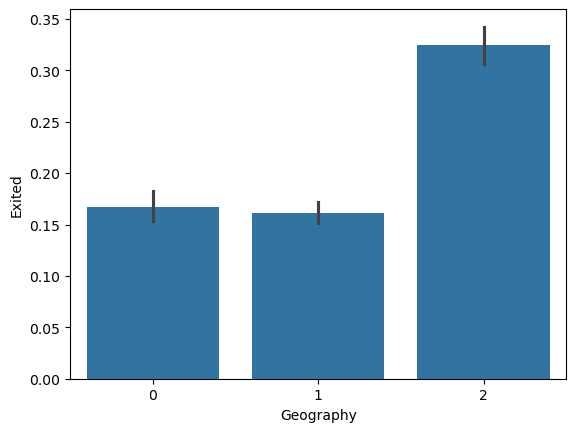

In [28]:
sns.barplot(x='Geography', y='Exited', data=df)

<Axes: xlabel='Gender', ylabel='Exited'>

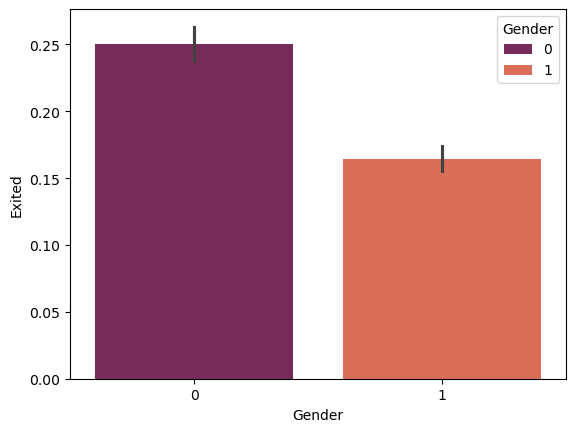

In [29]:
sns.barplot(x='Gender', y='Exited', data=df,palette='rocket', hue='Gender')

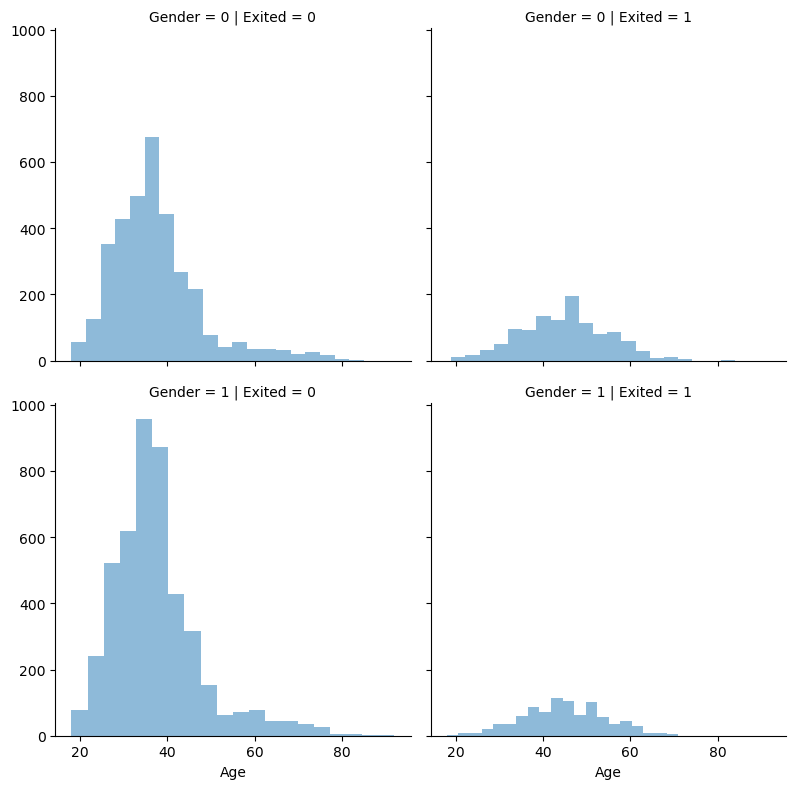

In [30]:
g = sns.FacetGrid(df, row='Gender', col='Exited', height=4)
g.map(plt.hist,'Age', alpha=0.5, bins=20)
g.add_legend()
plt.show()

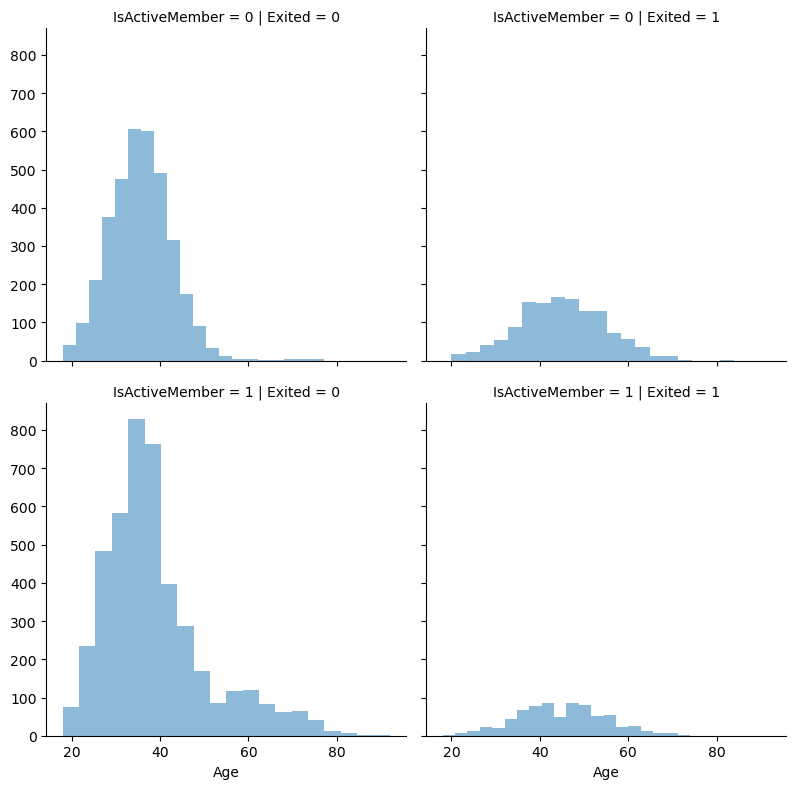

In [31]:
g = sns.FacetGrid(df, row='IsActiveMember', col='Exited', height=4)
g.map(plt.hist,'Age', alpha=0.5, bins=20)
g.add_legend()
plt.show()

In [32]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])

In [33]:
le_geo = LabelEncoder()
df['Geography'] = le_geo.fit_transform(df['Geography'])
print(df['Geography'].head())
df['Geography'].value_counts()

0    1
1    0
2    1
3    1
4    0
Name: Geography, dtype: int64


Geography
1    5014
2    2509
0    2477
Name: count, dtype: int64

In [34]:
X = df[['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']]
y = df['Exited']

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
X_train_scaled

array([[ 1.06200386e+00, -5.29866730e-04,  9.07507376e-01, ...,
         6.41041921e-01, -1.03020600e+00,  1.04208392e+00],
       [ 9.15339397e-01,  1.41244808e+00,  9.07507376e-01, ...,
         6.41041921e-01, -1.03020600e+00, -6.23556352e-01],
       [ 1.07925851e+00,  1.41244808e+00, -1.10191942e+00, ...,
         6.41041921e-01,  9.70679651e-01,  3.08127788e-01],
       ...,
       [ 1.64762429e-01, -5.29866730e-04, -1.10191942e+00, ...,
         6.41041921e-01,  9.70679651e-01, -5.58087669e-01],
       [ 3.71818144e-01, -1.41350781e+00,  9.07507376e-01, ...,
         6.41041921e-01, -1.03020600e+00, -1.35149956e+00],
       [ 1.56238851e+00, -1.41350781e+00,  9.07507376e-01, ...,
        -1.55996038e+00,  9.70679651e-01, -1.02692216e+00]])

In [37]:
X_test_scaled

array([[-6.80715076e-01, -5.29866730e-04,  9.07507376e-01, ...,
         6.41041921e-01, -1.03020600e+00, -9.50213835e-02],
       [-1.30188222e+00,  1.41244808e+00,  9.07507376e-01, ...,
        -1.55996038e+00, -1.03020600e+00, -7.78940999e-01],
       [-9.74044006e-01, -1.41350781e+00, -1.10191942e+00, ...,
        -1.55996038e+00,  9.70679651e-01,  9.94691424e-02],
       ...,
       [-1.39678276e+00,  1.41244808e+00, -1.10191942e+00, ...,
        -1.55996038e+00, -1.03020600e+00,  8.70085899e-01],
       [ 3.97700109e-01, -5.29866730e-04,  9.07507376e-01, ...,
        -1.55996038e+00, -1.03020600e+00, -1.47935555e+00],
       [ 1.02749458e+00, -5.29866730e-04,  9.07507376e-01, ...,
         6.41041921e-01, -1.03020600e+00, -4.95318546e-01]])

In [38]:
#Shape of train and test data
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (8000, 10) (8000,)
Test set: (2000, 10) (2000,)


In [39]:
# Using KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
#Train Model  
neigh = KNeighborsClassifier(n_neighbors = 4).fit(X_train_scaled,y_train)
#Prediction
prediction = neigh.predict(X_test_scaled)
prediction1=pd.DataFrame(prediction)
prediction1.head()

,0
0,0
1,0
2,0
3,0
4,0


In [40]:
#Accuracy
from sklearn import metrics
percent1 = metrics.accuracy_score(y_test, prediction)
percent1

0.8295

In [41]:
from sklearn.ensemble import RandomForestClassifier
classifier_4 = RandomForestClassifier(n_estimators=100) #warning 10 to 100
classifier_4.fit(X_train_scaled,y_train)

RandomForestClassifier()

In [42]:
#Predict
y_randomfor=classifier_4.predict(X_test_scaled)
prediction2=pd.DataFrame(y_randomfor)
prediction2.head()


,0
0,0
1,0
2,0
3,0
4,0


In [43]:
# Accuracy
percent2 = metrics.accuracy_score(y_test, prediction2)
percent2

0.863

In [44]:
#Using DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
TeleTree = DecisionTreeClassifier(criterion="entropy", max_depth = 4)
TeleTree.fit(X_train_scaled,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

In [45]:
y_predtree = TeleTree.predict(X_test_scaled)
prediction3=pd.DataFrame(y_predtree)
prediction3.head()

,0
0,0
1,0
2,0
3,0
4,0


In [46]:
#Accuracy
percent3 = metrics.accuracy_score(y_test,prediction3)
percent3

0.846

In [47]:
models = pd.DataFrame({'name_model':["KNN","Random Forest","Decision Trees"],\
                        'accuracy_percentage':[percent1,percent2,percent3]})
models.sort_values(by='accuracy_percentage',ascending=False)

,name_model,accuracy_percentage
1,Random Forest,0.8630
2,Decision Trees,0.8460
0,KNN,0.8295


In [48]:
# Tumhare models ka naam kya hai? Maan lete hai:
# model1 = KNN, model2 = Random Forest, model3 = Decision Tree

# 1. Random Forest ke liye (Tumhara best model - 0.8645 wala)
train_pred_rf = classifier_4.predict(X_train)  # model2 ka naam change kar lena
train_acc_rf = metrics.accuracy_score(y_train, train_pred_rf)
test_acc_rf = 0.8645 # tumhara wala

print(f"Random Forest - Train: {train_acc_rf:.4f}, Test: {test_acc_rf:.4f}, Gap: {train_acc_rf - test_acc_rf:.4f}")

# 2. Decision Tree ke liye (0.846 wala)
#train_pred_dt = Teletree.predict(X_train)
#train_acc_dt = metrics.accuracy_score(y_train, train_pred_dt)
#print(f"Decision Tree - Train: {train_acc_dt:.4f}, Test: 0.8460, Gap: {train_acc_dt - 0.8460:.4f}")

# 3. KNN ke liye (0.8295 wala)
train_pred_knn = neigh.predict(X_train)
train_acc_knn = metrics.accuracy_score(y_train, train_pred_knn)
print(f"KNN - Train: {train_acc_knn:.4f}, Test: 0.8295, Gap: {train_acc_knn - 0.8295:.4f}")

Random Forest - Train: 0.4279, Test: 0.8645, Gap: -0.4366
KNN - Train: 0.7812, Test: 0.8295, Gap: -0.0483


In [49]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test,prediction2))
print(classification_report(y_test,prediction2))

[[1535   58]
 [ 216  191]]
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.77      0.47      0.58       407

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [50]:
from sklearn.ensemble import RandomForestClassifier
model_final = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
model_final.fit(X_train_scaled,y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [51]:
# use random search to find the best hyperparameters for the Random Forest model
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}
random_search = RandomizedSearchCV(estimator=model_final, param_distributions=param_grid, n_iter=10, cv=5, verbose=2, random_state=42, n_jobs=-1)
random_search.fit(X_train_scaled, y_train)
print(f"Best hyperparameters: {random_search.best_params_}")
print(f"Best score: {random_search.best_score_:.4f}")
best_model = random_search.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best hyperparameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Best score: 0.8595


In [52]:
# check the accuracy of the best model on the test set
test_pred_best = best_model.predict(X_test_scaled)
test_acc_best = metrics.accuracy_score(y_test, test_pred_best)
print(f"Test accuracy of the best model: {test_acc_best:.4f}")
print(confusion_matrix(y_test, test_pred_best))
print(classification_report(y_test, test_pred_best))

Test accuracy of the best model: 0.8605
[[1538   55]
 [ 224  183]]
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.77      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



In [53]:
# final overfitting check
train_acc_best= best_model.score(X_train_scaled, y_train)
test_acc_best= best_model.score(X_test_scaled, y_test)
print(f"Best Model - Train: {train_acc_best:.4f}, Test: {test_acc_best:.4f}, Gap: {train_acc_best - test_acc_best:.4f}")

Best Model - Train: 1.0000, Test: 0.8605, Gap: 0.1395


In [54]:
from sklearn.ensemble import RandomForestClassifier

# to control overfitting, we can set the max_depth, min_samples_split, and min_samples_leaf parameters to appropriate values.
model_no_overfit = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,              
    min_samples_split=5,      
    min_samples_leaf=2,        
    class_weight='balanced',
    random_state=42
)

model_no_overfit.fit(X_train_scaled, y_train)

train_acc = model_no_overfit.score(X_train_scaled, y_train)
test_acc = model_no_overfit.score(X_test_scaled, y_test)

print(f"After Fix - Train: {train_acc:.4f}, Test: {test_acc:.4f}, Gap: {train_acc - test_acc:.4f}")

After Fix - Train: 0.9396, Test: 0.8515, Gap: 0.0881


In [57]:
# check the accuracy of the best model on the test set
test_pred_fixed = best_model.predict(X_test_scaled)
test_pred_fixed = model_no_overfit.predict(X_test_scaled)
print(confusion_matrix(y_test, test_pred_fixed))
print(classification_report(y_test, test_pred_fixed))

[[1455  138]
 [ 159  248]]
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      1593
           1       0.64      0.61      0.63       407

    accuracy                           0.85      2000
   macro avg       0.77      0.76      0.77      2000
weighted avg       0.85      0.85      0.85      2000

